### Problem Statement

You are a data scientist / AI engineer working on a classification problem to predict the likelihood of heart failure events based on clinical records. You have been provided with a dataset named **`"heart_failure_clinical_records.csv"`** which includes various clinical parameters of patients. The dataset comprises the following columns:

- age: Age of the patient (years)
- anaemia: Decrease of red blood cells or hemoglobin (boolean)
- creatinine_phosphokinase: Level of the CPK enzyme in the blood (mcg/L)
- diabetes: If the patient has diabetes (boolean)
- ejection_fraction: Percentage of blood leaving the heart at each contraction (percentage)
- high_blood_pressure: If the patient has hypertension (boolean)
- platelets: Platelets in the blood (kiloplatelets/mL)
- serum_creatinine: Level of serum creatinine in the blood (mg/dL)
- serum_sodium: Level of serum sodium in the blood (mEq/L)
- sex: Sex of the patient (binary, 1 for male, 0 for female)
- smoking: If the patient smokes or not (boolean)
- time: Follow-up period (days)
- death_event: If the patient died during the follow-up period (boolean)

Your task is to use this dataset to build and evaluate machine learning models to predict heart failure events. You will perform data preprocessing, exploratory data analysis, and model training using GaussianNB, SVM, and XGBoost. Additionally, you will use ROC curves to analyze model performance and make cost-benefit decisions.

**Dataset credits:** Heart Failure Clinical Records. (2020). UCI Machine Learning Repository. https://doi.org/10.24432/C5Z89R.



**Import Necessary Libraries**

In [1]:
# Import Necessary Libraries



### Task 1: Data Preprocessing and Exploratory Data Analysis

1. Import the data from the `"heart_failure_clinical_records.csv"` file and store it in a DataFrame.
2. Display the number of rows and columns in the dataset.
3. Display the first few rows of the dataset to get an overview.
4. Check for missing values and handle them appropriately.
5. Perform basic statistical analysis and visualization to understand the distribution of each feature.
    - Use `histograms` for continuous features (age, creatinine_phosphokinase, ejection_fraction, platelets, serum_creatinine, serum_sodium, time).
    - Use `bar plots` for binary features (anaemia, diabetes, high_blood_pressure, sex, smoking).

In [2]:
import pandas as pd

# Import the data from the "heart_failure_clinical_records.csv" file and store it in a DataFrame.
df = pd.read_csv("heart_failure_clinical_records.csv")

# Display the number of rows and columns in the dataset.
print(df.shape)

# Display the first few rows of the dataset to get an overview
df.head()

(5000, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,death_event
0,55.0,0,748,0,45,0,263358.03,1.3,137,1,1,88,0
1,65.0,0,56,0,25,0,305000.00,5.0,130,1,0,207,0
2,45.0,0,582,1,38,0,319000.00,0.9,140,0,0,244,0
3,60.0,1,754,1,40,1,328000.00,1.2,126,1,0,90,0
4,95.0,1,582,0,30,0,461000.00,2.0,132,1,0,50,1


In [3]:
# Check for missing values and handle them appropriately.

df.isna().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
death_event                 0
dtype: int64

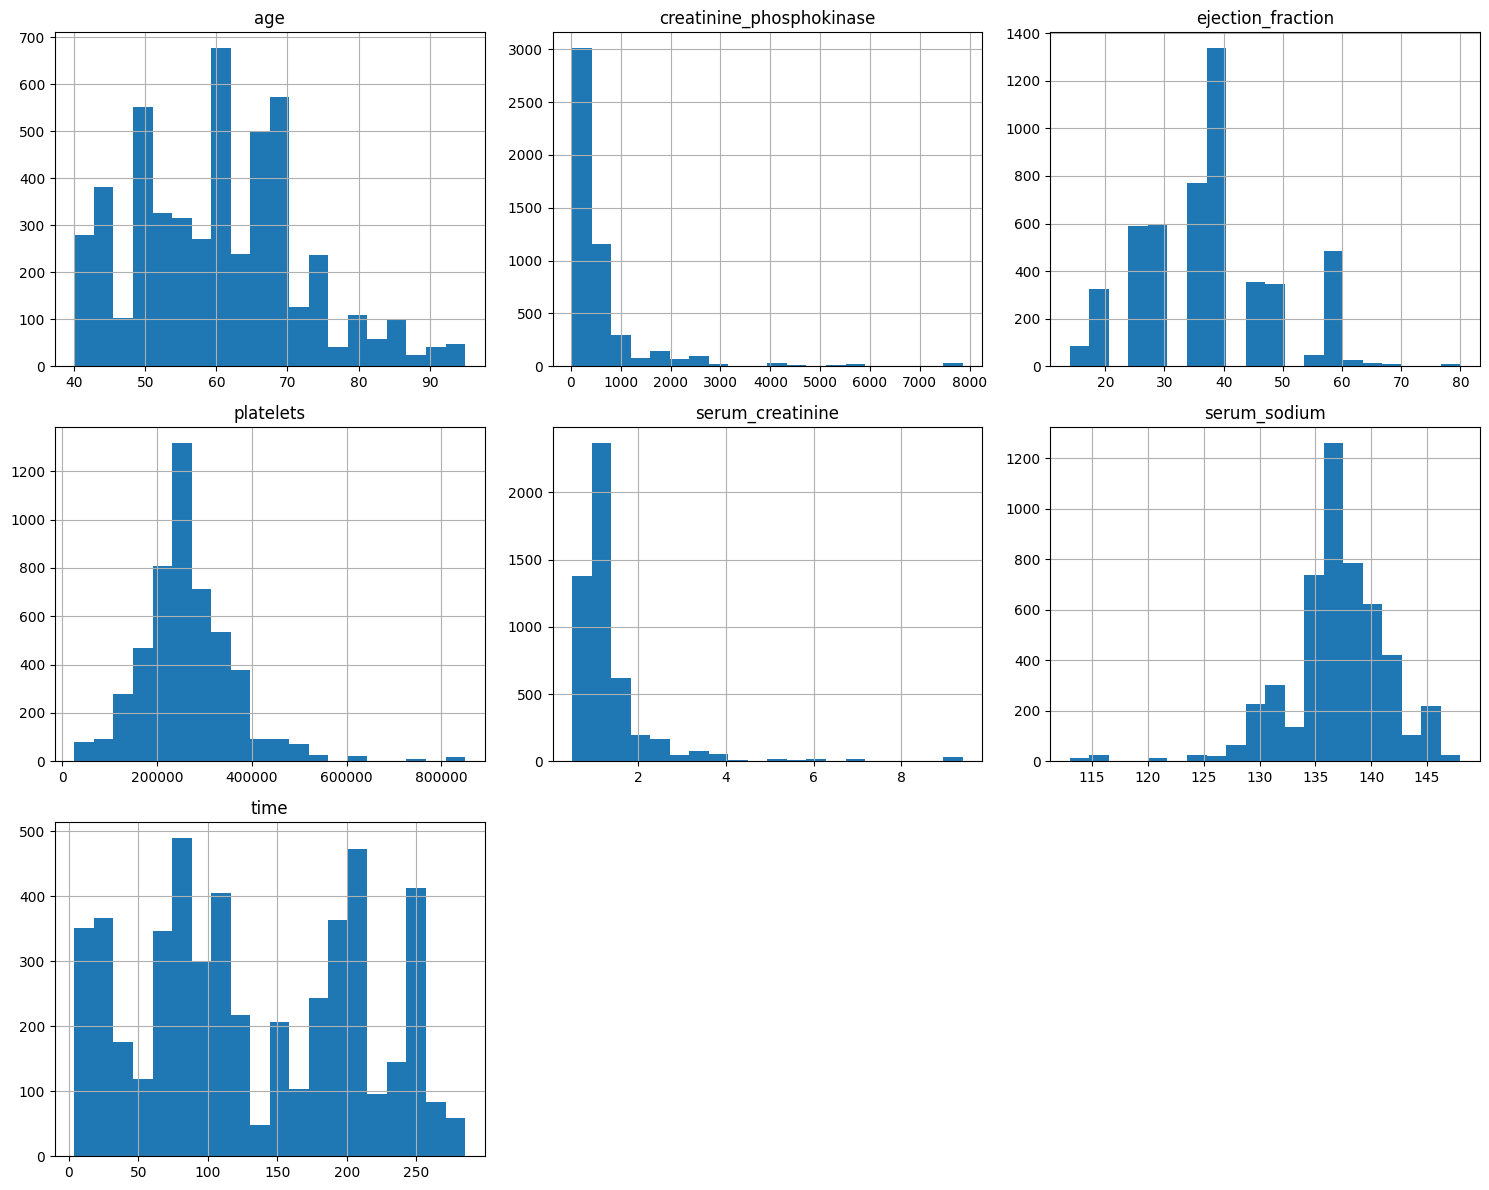

In [4]:
import matplotlib.pyplot as plt

features = ["age", "creatinine_phosphokinase", "ejection_fraction", "platelets", "serum_creatinine", "serum_sodium", "time"]

# Select the columns and call .hist()
df[features].hist(figsize=(15, 12), bins=20) # You can adjust figsize and bins

plt.tight_layout() # Adjusts plot to ensure everything fits without overlapping
plt.show()

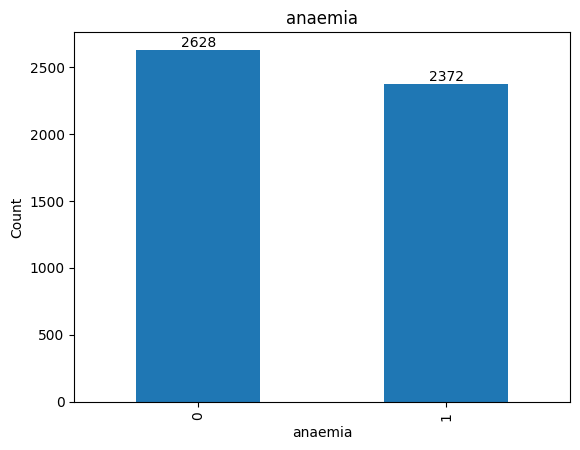

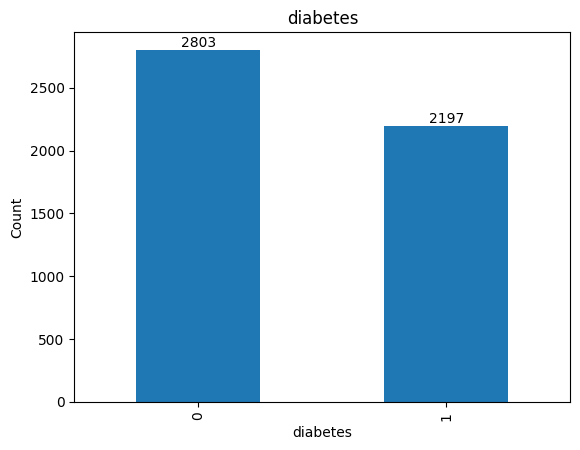

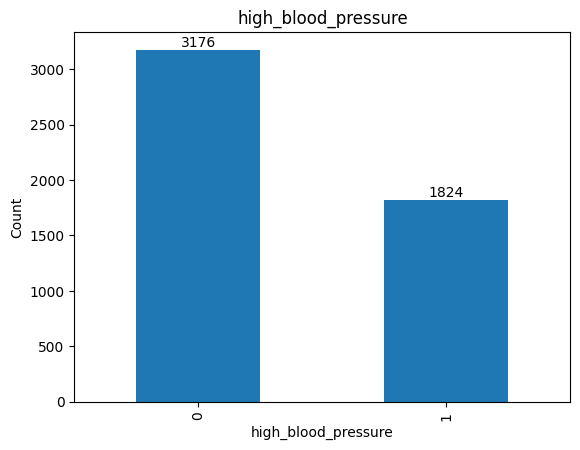

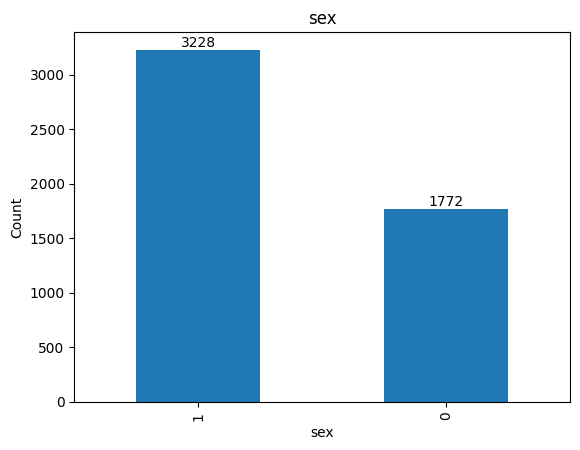

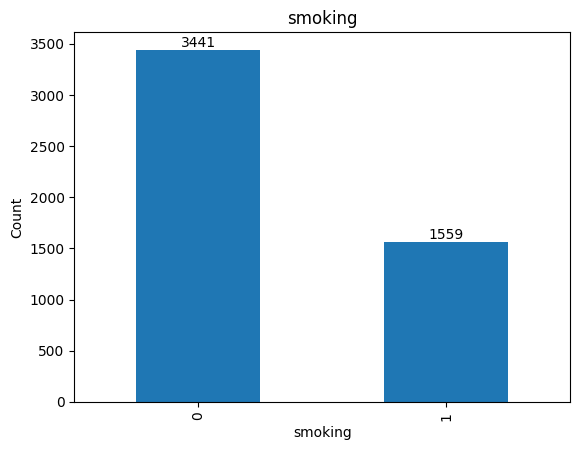

In [5]:
# Bar plots for binary features (anaemia, diabetes, high_blood_pressure, sex, smoking).

binary_features = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]

for feature in binary_features:
    ax = df[feature].value_counts().plot(kind='bar')
    plt.title(feature)
    plt.ylabel('Count')

    for i in ax.containers:
        ax.bar_label(i)
        
    plt.show()    

### Task 2: Feature Transformation

1. Split the dataset into training and test sets with a test size of 25%.
2. Normalize continuous features (age, creatinine_phosphokinase, ejection_fraction, platelets, serum_creatinine, serum_sodium, time) using StandardScaler.

In [6]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and test sets
X = df.drop("death_event", axis=1)
y = df["death_event"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=9)

In [7]:
from sklearn.preprocessing import StandardScaler

# Normalize continuous features using StandardScaler
continuous_features = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']
scaler = StandardScaler()
X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test[continuous_features] = scaler.transform(X_test[continuous_features])

### Task 3: Model Training and Evaluation with GaussianNB

1. Initialize and train a `GaussianNB` model using the training data.
2. Print the classification report to evaluate the model's performance.
3. Calculate the AUC for the GaussianNB model.
4. Find the probability threshold associated with a desired recall of 85% and print the corresponding false positive rate.

In [8]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, roc_curve, auc

# Initialize and train a GaussianNB model
model_NB = GaussianNB()
model_NB.fit(X_train, y_train)

# Print the classification report
y_pred_NB = model_NB.predict(X_test)
report = classification_report(y_test, y_pred_NB)
print(report)

              precision    recall  f1-score   support

           0       0.80      0.94      0.87       854
           1       0.79      0.50      0.62       396

    accuracy                           0.80      1250
   macro avg       0.80      0.72      0.74      1250
weighted avg       0.80      0.80      0.79      1250



In [11]:
# Calculate the AUC for the GaussianNB model.

probabilities_NB = model_NB.predict_proba(X_test)[:, 1]
fpr_NB, tpr_NB, thresholds_NB = roc_curve(y_test, probabilities_NB)
roc_auc_NB = auc(fpr_NB, tpr_NB)
print("AUC for GaussianNB:", roc_auc_NB)

AUC for GaussianNB: 0.8953912662929057


In [13]:
import numpy as np

# Find the probability threshold associated with 85% recall
desired_recall = 0.85
closest_index = np.argmin(abs(tpr_NB - desired_recall))
optimal_threshold_NB = thresholds_NB[closest_index]
optimal_fpr_NB = fpr_NB[closest_index]
optimal_tpr_NB = tpr_NB[closest_index]
print(f"Optimal threshold for 85% recall: {optimal_threshold_NB}, FPR: {optimal_fpr_NB}, TPR: {optimal_tpr_NB}")

Optimal threshold for 85% recall: 0.12061311823124941, FPR: 0.18149882903981265, TPR: 0.8434343434343434


### Task 4: Model Training and Evaluation with SVM

1. Initialize and train an `SVM` model with a linear kernel using the training data.
2. Print the classification report to evaluate the model's performance.
3. Calculate the AUC for the SVM model.
4. Find the probability threshold associated with a desired recall of 90% and print the corresponding false positive rate.

In [20]:
from sklearn.svm import SVC

# Initialize and train an SVM model with a linear kernel
model_SVM = SVC(kernel='linear', probability=True)
model_SVM.fit(X_train, y_train)

# Print the classification report
y_pred_SVM = model_SVM.predict(X_test)
report = classification_report(y_test, y_pred_SVM)
print(report)

              precision    recall  f1-score   support

           0       0.89      0.93      0.91       854
           1       0.83      0.74      0.78       396

    accuracy                           0.87      1250
   macro avg       0.86      0.84      0.85      1250
weighted avg       0.87      0.87      0.87      1250



In [21]:
# Calculate the AUC
probabilities_SVM = model_SVM.predict_proba(X_test)[:,1]
fpr_SVM, tpr_SVM, thresholds_SVM  = roc_curve(y_test, probabilities_SVM)
roc_auc_SVM = auc(fpr_SVM, tpr_SVM)
print("AUC for SVM:", roc_auc_SVM)

AUC for SVM: 0.9047737326425851


In [23]:
# Find the probability threshold associated with 90% recall

desired_recall = 0.90
closest_index = np.argmin(abs(tpr_SVM-desired_recall))
optimal_threshold_SVM, optimal_fpr_SVM, optimal_tpr_SVM = thresholds_NB[closest_index], fpr_SVM[closest_index], tpr_SVM[closest_index]
print(f"Optimal threshold for 85% recall: {optimal_threshold_SVM}, FPR: {optimal_fpr_SVM}, TPR: {optimal_tpr_SVM}")

Optimal threshold for 85% recall: 0.061105481054502524, FPR: 0.32435597189695553, TPR: 0.9015151515151515


### Task 5: Model Training and Evaluation with XGBoost

1. Initialize and train an `XGBoost` model using the training data.
2. Print the classification report to evaluate the model's performance.
3. Calculate the AUC for the XGBoost model.

In [24]:
from xgboost import XGBClassifier

# Initialize and train an XGBoost model
model_XGBC = XGBClassifier()
model_XGBC.fit(X_train, y_train)

# Print the classification report
y_pred_XGBC = model_XGBC.predict(X_test)
report = classification_report(y_test, y_pred_XGBC)
print(report)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       854
           1       1.00      0.99      0.99       396

    accuracy                           1.00      1250
   macro avg       1.00      0.99      0.99      1250
weighted avg       1.00      1.00      1.00      1250



In [25]:
# Calculate the AUC

probabilities_XGBC = model_XGBC.predict_proba(X_test)[:,1]
fpr_XGBC, tpr_XGBC, thresholds_XGBC = roc_curve(y_test, probabilities_XGBC)
calc_auc = auc(fpr_XGBC, tpr_XGBC)
print(calc_auc)

0.9993819932344522


### Task 6: Summary and Conclusion

1. Plot the ROC curves for `GaussianNB, SVM, and XGBoost` models on the same chart.
2. Summarize the results and compare the performance of the models.

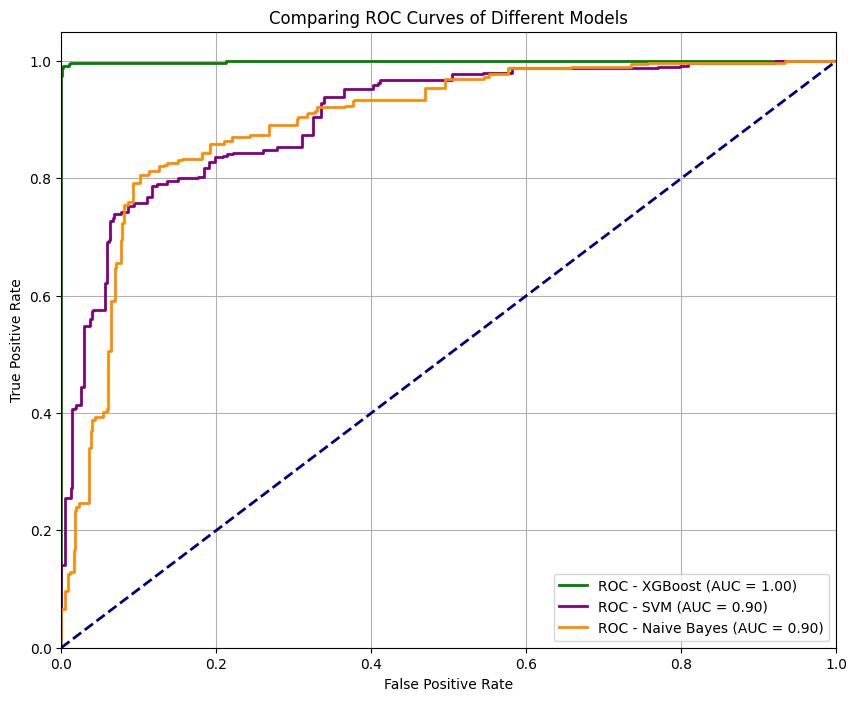

In [26]:
# Plot the ROC curves for all models

import matplotlib.pyplot as plt

# Create a single figure to hold all the plots
plt.figure(figsize=(10, 8)) # Making the plot a bit bigger for clarity

# --- Plot the ROC Curve for each model ---

# Plot for XGBoost (Green)
plt.plot(fpr_XGBC, tpr_XGBC, color='green', lw=2, 
         label=f'ROC - XGBoost (AUC = {calc_auc:.2f})')

# Plot for SVM (Purple)
plt.plot(fpr_SVM, tpr_SVM, color='purple', lw=2, 
         label=f'ROC - SVM (AUC = {roc_auc_SVM:.2f})')

# Plot for Gaussian Naive Bayes (Orange)
plt.plot(fpr_NB, tpr_NB, color='darkorange', lw=2, 
         label=f'ROC - Naive Bayes (AUC = {roc_auc_NB:.2f})')


# --- Add the standard elements to the plot ---

# Plot the "random guess" line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Set the limits and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparing ROC Curves of Different Models')

# Add the legend to show what each line is
plt.legend(loc="lower right")

# Add a grid for easier reading
plt.grid()

# Display the final plot
plt.show()

### Conclusion

--------
--------


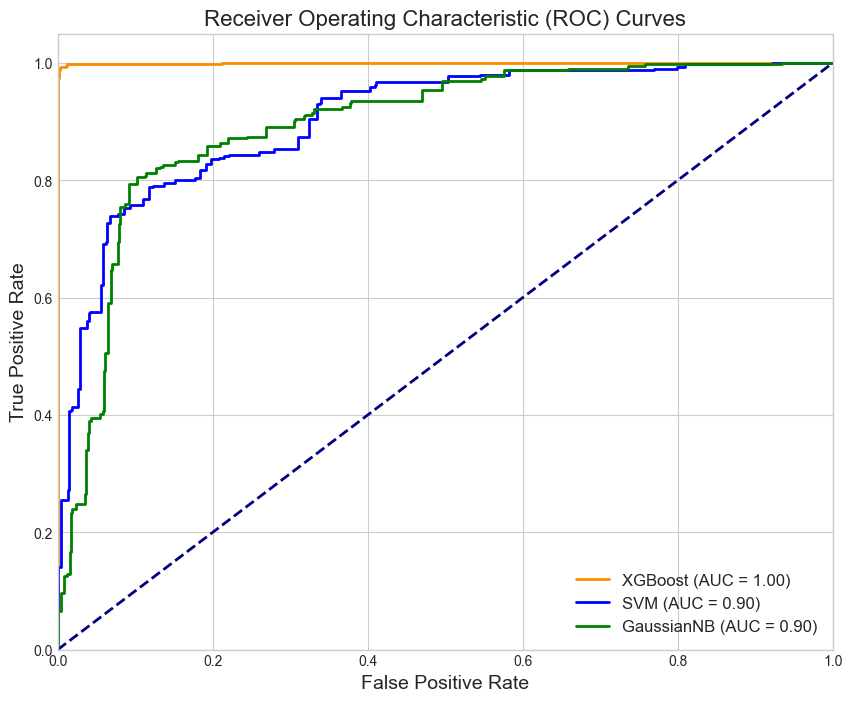

In [29]:
 # --- 3. Plot all ROC Curves on a single graph ---

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 8))

# Plot the ROC curve for each model
plt.plot(fpr_XGBC, tpr_XGBC, color='darkorange', lw=2,
         label=f'XGBoost (AUC = {calc_auc:.2f})')
plt.plot(fpr_SVM, tpr_SVM, color='blue', lw=2,
         label=f'SVM (AUC = {roc_auc_SVM:.2f})')
plt.plot(fpr_NB, tpr_NB, color='green', lw=2,
         label=f'GaussianNB (AUC = {roc_auc_NB:.2f})')

# Plot the diagonal line (representing a random classifier)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Set plot labels and title
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=16)
plt.legend(loc="lower right", fontsize=12)

# Show the plot
plt.show()